## **EMNIST Letter Classification using HOG (Histogram of Oriented Gradients) feature extractor and SVM (Support Vector Machine) classifier**

**1. Pre-requisites**

Installation of the following dependencies

In [3]:
!pip3 install matplotlib numpy seaborn scikit-learn scikit-image mlxtend

**2. Dataset Preparation**

Importing the required libraries as follows:

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mlxtend.data import loadlocal_mnist

To confirm whether the dataset already downloaded, use this following command

In [51]:
data_img, data_labels = loadlocal_mnist(
    images_path="datasets/emnist-letters-train-images-idx3-ubyte",
    labels_path="datasets/emnist-letters-train-labels-idx1-ubyte",
)

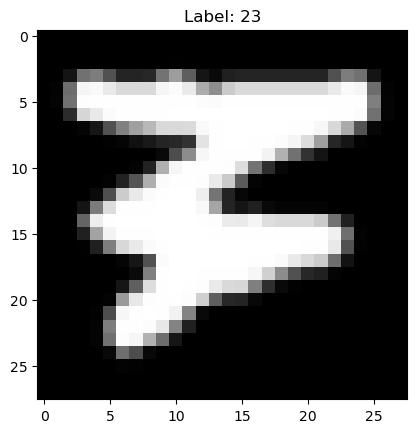

In [52]:
plt.imshow(data_img[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {data_labels[0]}")
plt.show()

In [53]:
print("Total images:", len(data_img))
print("Total labels:", len(data_labels))

Total images: 124800
Total labels: 124800


In [54]:
data_labels = data_labels - 1

In [55]:
data_img = np.array(data_img)
data_labels = np.array(data_labels)

selected_img = []
selected_labels = []

for class_idx in range(26):
    idx = np.where(data_labels == class_idx)[0]
    if len(idx) >= 100:
        selected_idx = np.random.choice(idx, 100, replace=False)
        selected_img.append(data_img[selected_idx])
        selected_labels.append(data_labels[selected_idx])
    else:
        print(f"Class {class_idx} has only {len(idx)} samples, skipping.")

X_subset = np.vstack(selected_img)
y_subset = np.hstack(selected_labels)

print("x_subset shape:", X_subset.shape)
print("y_subset shape:", y_subset.shape)

x_subset shape: (2600, 784)
y_subset shape: (2600,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

print("x_train shape:", len(X_train))
print("y_train shape:", len(y_train))
print("x_test shape:", len(X_test))
print("y_test shape:", len(y_test))

x_train shape: 2080
y_train shape: 2080
x_test shape: 520
y_test shape: 520


**2. Feature Extraction using HOG**

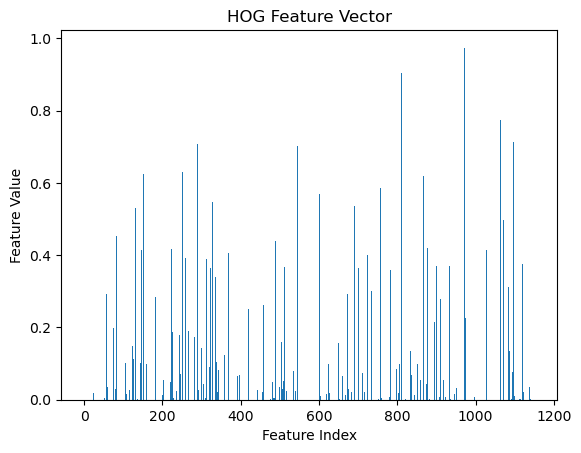

In [57]:
feature, hog_img = hog(X_train[0].reshape(28, 28), orientations = 8, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=True, block_norm='L2')
feature.shape

plt.bar(list(range(feature.shape[0])), feature)
plt.title("HOG Feature Vector")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.show()

In [58]:
def hog_features(images, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    features = []
    for img in images:
        feature = hog(img.reshape(28, 28), orientations=orientations, 
                      pixels_per_cell=pixels_per_cell, 
                      cells_per_block=cells_per_block, 
                      block_norm='L2')
        features.append(feature)
    return np.array(features)

In [59]:
orientations = 8
pixels_per_cell = (4, 4)
cells_per_block = (2, 2)

In [60]:
X_train_hog = hog_features(X_train, orientations, pixels_per_cell, cells_per_block)
X_test_hog = hog_features(X_test, orientations, pixels_per_cell, cells_per_block)

print("HOG feature shape for training set:", X_train_hog.shape)
print("HOG feature shape for test set:", X_test_hog.shape)

HOG feature shape for training set: (2080, 1152)
HOG feature shape for test set: (520, 1152)


**3. Classification using SVM**

In [61]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [62]:
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, verbose=2)

In [63]:
grid_search.fit(X_train_hog, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [45]:
print("Best parameters found: ", grid_search.best_params_)
print("Performance:", grid_search.best_estimator_.score(X_test_hog, y_test))

Best parameters found:  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Performance: 0.8442307692307692


In [46]:
best_model = grid_search.best_estimator_

**4. Evaluation**

In [64]:
y_test_pred = best_model.predict(X_test_hog)\

print("---Test Set Evaluation---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\n Classification Report:\n", classification_report(y_test, y_test_pred))

---Test Set Evaluation---
Accuracy: 0.8365384615384616

 Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.60      0.63        20
           1       0.90      0.90      0.90        20
           2       0.75      0.90      0.82        20
           3       0.86      0.95      0.90        20
           4       0.93      0.70      0.80        20
           5       0.93      0.70      0.80        20
           6       0.89      0.80      0.84        20
           7       0.75      0.90      0.82        20
           8       0.67      0.80      0.73        20
           9       0.90      0.95      0.93        20
          10       0.76      0.80      0.78        20
          11       0.71      0.60      0.65        20
          12       0.95      0.95      0.95        20
          13       0.79      0.75      0.77        20
          14       0.90      0.95      0.93        20
          15       0.78      0.90      0.84        20


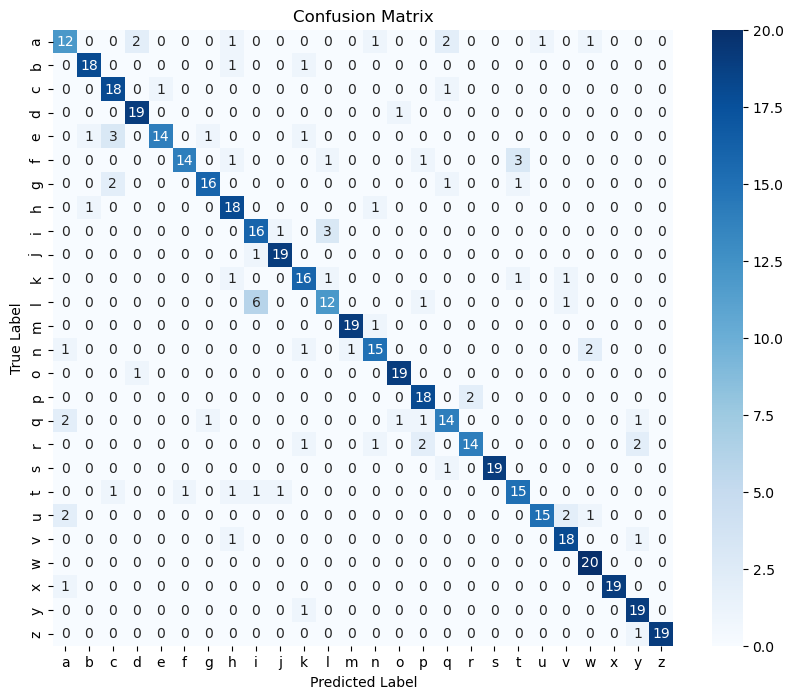

In [65]:
c_mat = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(c_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=[chr(i + 97) for i in range(26)],
            yticklabels=[chr(i + 97) for i in range(26)])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**5. Prediction Results**

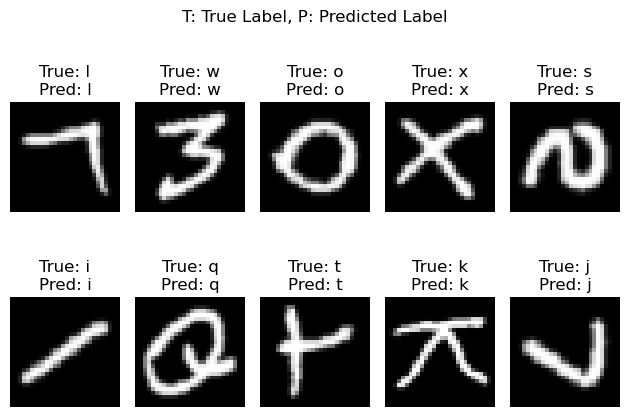

In [73]:
indices = random.sample(range(len(X_test)), 10)

for i, idx in enumerate(indices):
    img = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_test_pred[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {chr(true_label + 97)}\nPred: {chr(pred_label + 97)}")
    plt.axis('off')

plt.suptitle("T: True Label, P: Predicted Label")
plt.tight_layout()
plt.show()